In [2]:
# Install Required Libraries

!pip install pandas scikit-learn numpy seaborn matplotlib

In [3]:
# Import libraries

import pandas as pd 
import numpy as np

In [5]:
df = pd.read_csv("pakistan_maritime_trade_2020_2026 (1).csv")

df.head(3)

,Shipment_ID,Year,Month,Quarter,Departure_Date,Arrival_Date,Transit_Days,Customs_Clearance_Days,Trade_Direction,Trade_Category,...,Insurance_Pct,Insurance_Cost_USD,Bunker_Fuel_Consumed_MT,Bunker_Price_USD_per_MT,Bunker_Cost_USD,Total_Voyage_Cost_USD,Customs_Cleared,ISM_Certified,Safety_Incident,Environmental_Flag
0,PKT-2020-00001,2023,1,Q1,2023-01-31,2023-02-12,12,NaN,Import,Energy & Petroleum,...,0.105,18748.04,431.9,522.78,225788.68,7262722.20,Yes,Yes,NaN,Clean
1,PKT-2020-00002,2025,1,Q1,2025-01-13,2025-02-07,25,12.8,Export,Manufactured Goods,...,0.232,5712.22,440.1,729.55,321074.96,654760.69,Yes,Yes,NaN,Clean
2,PKT-2020-00003,2020,6,Q2,2020-06-26,2020-07-26,30,14.3,Export,Agri-commodities,...,0.206,67461.28,671.8,737.83,495674.19,2945148.47,Yes,Yes,NaN,Clean


In [6]:
df.shape

(5000, 47)

In [7]:
df.columns

Index(['Shipment_ID', 'Year', 'Month', 'Quarter', 'Departure_Date',
       'Arrival_Date', 'Transit_Days', 'Customs_Clearance_Days',
       'Trade_Direction', 'Trade_Category', 'Cargo_Type', 'HS_Code',
       'Incoterms', 'Payment_Terms', 'Currency', 'Port_of_Loading',
       'Port_of_Discharge', 'Vessel_Name', 'Vessel_Type', 'Vessel_Flag',
       'Shipping_Line', 'Vessel_DWT_MT', 'Gross_Tonnage_GT',
       'Vessel_Age_Years', 'Average_Speed_Knots', 'Cargo_Volume_MT',
       'TEU_Count', 'Freight_Rate_USD_per_Unit', 'Total_Freight_USD',
       'Cargo_Value_USD', 'PKR_USD_Exchange_Rate', 'Cargo_Value_PKR',
       'Port_Charges_USD', 'Demurrage_Days', 'Demurrage_Cost_USD',
       'Import_Duty_Pct', 'Import_Duty_USD', 'Insurance_Pct',
       'Insurance_Cost_USD', 'Bunker_Fuel_Consumed_MT',
       'Bunker_Price_USD_per_MT', 'Bunker_Cost_USD', 'Total_Voyage_Cost_USD',
       'Customs_Cleared', 'ISM_Certified', 'Safety_Incident',
       'Environmental_Flag'],
      dtype='object')

In [8]:
shipping_data = shipping_data = df[[ 
    "Cargo_Volume_MT",
    "Trade_Direction",
    "Cargo_Type",
    "Incoterms",
    "Port_of_Loading",
    "Port_of_Discharge",
    "Vessel_Type",
    "Transit_Days",
    "Total_Freight_USD"
]]

In [9]:
shipping_data.head(3)

,Cargo_Volume_MT,Trade_Direction,Cargo_Type,Incoterms,Port_of_Loading,Port_of_Discharge,Vessel_Type,Transit_Days,Total_Freight_USD
0,206181.02,Import,Crude Oil,EXW,"Nhava Sheva, India",Gwadar Port,VLCC,12,6942114.94
1,5785.98,Export,Machinery,FOB,Pakistan Steel Jetty,"Port Rashid, UAE",Break Bulk Vessel,25,186250.70
2,57037.70,Export,Corn,FAS,Qasim International Container Terminal (QICT),"Sohar, Oman",Bulk Carrier (Supramax),30,2206218.24


In [10]:
shipping_data.shape

(5000, 9)

In [11]:
shipping_data.isnull().sum()

Cargo_Volume_MT      0
Trade_Direction      0
Cargo_Type           0
Incoterms            0
Port_of_Loading      0
Port_of_Discharge    0
Vessel_Type          0
Transit_Days         0
Total_Freight_USD    0
dtype: int64

In [12]:
shipping_data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Cargo_Volume_MT,5000.0,NaN,NaN,NaN,58650.570788,60175.945115,2016.85,17328.3525,42371.47,73760.3125,299985.15
Trade_Direction,5000,2,Export,2507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cargo_Type,5000,28,Crude Oil,805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incoterms,5000,6,EXW,854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Port_of_Loading,5000,28,"Port Qasim, Karachi",335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Port_of_Discharge,5000,28,"Port Qasim, Karachi",343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vessel_Type,5000,11,Bulk Carrier (Handymax),483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transit_Days,5000.0,NaN,NaN,NaN,16.789,7.324562,5.0,11.0,16.0,21.25,35.0
Total_Freight_USD,5000.0,NaN,NaN,NaN,1707250.11371,1621218.481582,28956.36,580114.54,1244750.98,2225941.0725,10080216.6


In [13]:
# Deal with Outlier in Cargo_Volume_MT, Transit_Days, Total_Freight_USD

<function matplotlib.pyplot.show(close=None, block=None)>

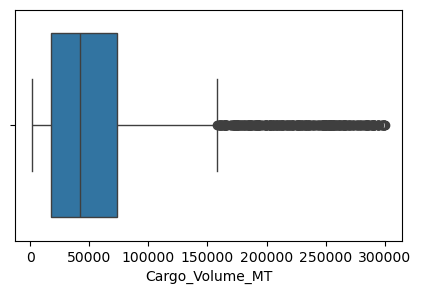

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='Cargo_Volume_MT')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

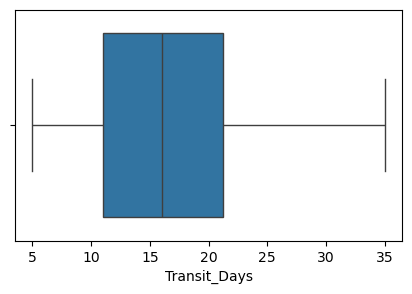

In [15]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='Transit_Days')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

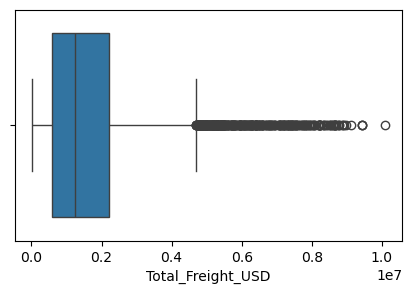

In [38]:
import seaborn as sns
plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='Total_Freight_USD')
plt.show

In [ ]:
## Outlier Analysis

# Boxplots were used to detect potential outliers in the numerical features.

# - Cargo_Volume_MT and Total_Freight_USD contain several high-value observations according to the IQR method.
# - Transit_Days does not show significant outliers.
# - Since this dataset represents real-world maritime shipments, the extreme values are likely valid business cases (e.g., large vessels carrying large cargo volumes) rather than data entry errors.

# Therefore, no outliers were removed from the dataset before model training.

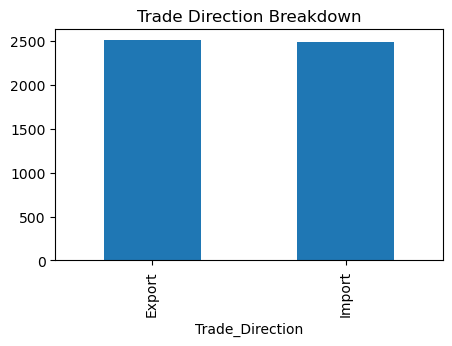

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
shipping_data['Trade_Direction'].value_counts().plot(kind='bar')
plt.title('Trade Direction Breakdown')
plt.show()

In [17]:
categorical_cols = [
    "Trade_Direction",
    "Cargo_Type",
    "Incoterms",
    "Port_of_Loading",
    "Port_of_Discharge",
    "Vessel_Type"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(shipping_data[col].value_counts())


Trade_Direction
Trade_Direction
Export    2507
Import    2493
Name: count, dtype: int64

Cargo_Type
Cargo_Type
Crude Oil                   805
Clean Petroleum Products    373
Project Cargo               335
Naphtha                     275
Jet Fuel                    275
Mixed General Cargo         254
Machinery                   227
Fuel Oil                    181
General Merchandise         126
DAP Fertilizer              126
Urea                        123
Palm Oil                    122
Sugar                       122
Steel Coils                 120
Fertilizer                  119
Soybean                     119
Steel Scrap                 117
Rice                        117
Wheat                       112
Electronics                 112
Corn                        112
Lubricants                  111
Clinker                     109
Coal                        107
Textiles                    105
Gasoline                    100
Pipes                        98
Diesel                  

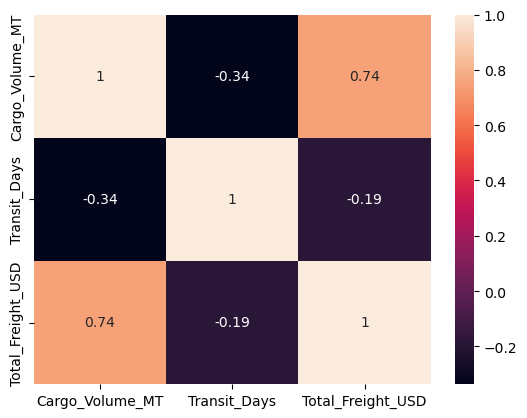

In [18]:
corr = shipping_data[['Cargo_Volume_MT', 'Transit_Days', 'Total_Freight_USD']].corr()

sns.heatmap(corr, annot=True)
plt.show()

In [46]:
## Correlation Analysis

# The correlation matrix was used to examine the relationships between the numerical variables.

# - Cargo_Volume_MT has a strong positive correlation (0.74) with **Total_Freight_USD**, indicating that larger cargo volumes generally result in higher freight costs.
# - Transit_Days has a weak negative correlation (-0.19) with **Total_Freight_USD**, suggesting that voyage duration alone is not a strong predictor of freight cost.
# - Cargo_Volume_MT and Transit_Days show a moderate negative correlation (-0.34), indicating a slight inverse relationship.

# Overall, Cargo_Volume_MT appears to be the strongest numerical predictor of Total_Freight_USD.

In [47]:
# One-hot Encoding Recommendation

# Since have:

# 5,000 rows
# 28 Cargo Types
# 28 Loading Ports
# 28 Discharge Ports
# 11 Vessel Types

In [19]:
from sklearn.preprocessing import OneHotEncoder

# 1. Select categorical columns
categorical_features = shipping_data[["Trade_Direction","Cargo_Type","Incoterms","Port_of_Loading","Port_of_Discharge","Vessel_Type"]]

# 2. Encode
encoder = OneHotEncoder()
encoded_data = encoder.fit_transform(categorical_features)

# 3. Convert to DataFrame
encoded_df = pd.DataFrame(encoded_data.toarray())
encoded_df.columns = encoder.get_feature_names_out()

# 4. Remove old categorical columns
shipping_data = shipping_data.drop(columns=categorical_features.columns)

# 5. Add new encoded columns
shipping_data = pd.concat([shipping_data, encoded_df], axis=1)

shipping_data.head()

,Cargo_Volume_MT,Transit_Days,Total_Freight_USD,Trade_Direction_Export,Trade_Direction_Import,Cargo_Type_Clean Petroleum Products,Cargo_Type_Clinker,Cargo_Type_Coal,Cargo_Type_Corn,Cargo_Type_Crude Oil,...,Vessel_Type_Break Bulk Vessel,Vessel_Type_Bulk Carrier (Handymax),Vessel_Type_Bulk Carrier (Panamax),Vessel_Type_Bulk Carrier (Supramax),Vessel_Type_Container Ship,Vessel_Type_General Cargo Ship,Vessel_Type_LR1 Tanker,Vessel_Type_LR2 Tanker,Vessel_Type_MR Tanker,Vessel_Type_VLCC
0,206181.02,12,6942114.94,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,5785.98,25,186250.70,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57037.70,30,2206218.24,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,266269.92,8,8885427.23,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,171138.63,17,5075971.77,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
X = shipping_data.drop("Total_Freight_USD", axis=1) # Features

y = shipping_data["Total_Freight_USD"] # Target

In [21]:
print(X.shape)
print(y.shape)

(5000, 105)
(5000,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4000, 105)
X_test shape: (1000, 105)
y_train shape: (4000,)
y_test shape: (1000,)


In [24]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_lr = lr_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE: 527805.7310605859
MSE: 603041449685.1283
R2 Score: 0.7224666008396624


In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [29]:
y_pred_gbr = gb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("MSE:", mean_squared_error(y_test, y_pred_gbr))
print("R2 Score:", r2_score(y_test, y_pred_gbr))

MAE: 497223.8093239573
MSE: 559247103716.2462
R2 Score: 0.7426217555261172


In [30]:
# Save model

import pickle

pickle.dump(encoder, open("encoder.pkl", "wb"))
pickle.dump(gb_model, open("ShippingCostPredication.pkl", "wb"))

print("Model saved successfully")

Model saved successfully
